# Confronto Pratico: Watershed vs. K-Means em Objetos Sobrepostos
**UFPI - Campus Senador Helvidio Nunes de Barros**  
**Disciplina:** Topicos Especiais em Visao Computacional - Prof. Jose Denes Lima Araujo  
**Grupo 4:** Segmentacao Baseada em Regiao (Secao 10.5 - Gonzalez & Woods)  
**Parte Pratica:** Integrante 3 (Analise Comparativa - Slide 11)

---

### Questao Pratica da Apresentacao
*"Por que nao podemos simplesmente aplicar o algoritmo K-Means para segmentar e contar moedas ou celulas que estao se tocando?"*

Neste notebook, aplicamos ambos os metodos exatamente na mesma imagem de teste de moedas em contato para comprovar empiricamente a resposta.


In [ ]:
# Instalacao das dependencias para execucao no Google Colab
!pip install -q opencv-python numpy matplotlib scikit-image scipy

In [ ]:
import os
import urllib.request
import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

os.makedirs("imagens", exist_ok=True)
os.makedirs("resultados", exist_ok=True)

img_path = os.path.join("imagens", "moedas_sobrepostas.jpg")
if not os.path.exists(img_path):
    url = "https://raw.githubusercontent.com/opencv/opencv/4.x/doc/py_tutorials/py_imgproc/py_watershed/images/water_coins.jpg"
    urllib.request.urlretrieve(url, img_path)

img_bgr = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

### 1. Aplicacao do K-Means na Imagem de Moedas
Como a cena contem moedas de bronze sobre fundo claro, aplicamos K-Means com K=2 para separar moedas do fundo.
Em seguida, calculamos os componentes conexos resultantes da mascara de moedas.


In [ ]:
# K-Means com K=2
pixels = img_rgb.reshape((-1, 3)).astype(np.float32)
criterio = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)

_, labels_k2, centers_k2 = cv2.kmeans(pixels, 2, None, criterio, 10, cv2.KMEANS_RANDOM_CENTERS)
seg_k2 = np.uint8(centers_k2)[labels_k2.flatten()].reshape(img_rgb.shape)
mapa_k2 = labels_k2.reshape((img_rgb.shape[0], img_rgb.shape[1]))

# Identifica qual cluster corresponde as moedas (o de menor luminosidade media)
cluster_moeda = np.argmin(np.mean(centers_k2, axis=1))
mascara_moedas_kmeans = np.uint8(mapa_k2 == cluster_moeda)

# Contagem de componentes conexos a partir do K-Means
num_comp_kmeans, _ = cv2.connectedComponents(mascara_moedas_kmeans)
qtd_kmeans = num_comp_kmeans - 1

print(f"K-Means (K=2) - Componentes conexos encontrados: {qtd_kmeans}")
print("Diagnostico: Como as moedas encostadas possuem a mesma cor, o K-Means agrupa todas no mesmo cluster espectral.")


K-Means (K=2) - Componentes conexos encontrados: 2
Diagnostico: Como as moedas encostadas possuem a mesma cor, o K-Means agrupa todas no mesmo cluster espectral.


### 2. Aplicacao do Watershed na Mesma Imagem
Executamos o pipeline de Watershed baseado em marcadores e Transformada de Distancia.


In [ ]:
# Pipeline de Watershed
_, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
kernel = np.ones((3, 3), np.uint8)
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)
sure_bg = cv2.dilate(opening, kernel, iterations=3)

dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
_, sure_fg = cv2.threshold(dist_transform, 0.7 * dist_transform.max(), 255, 0)
sure_fg = np.uint8(sure_fg)

unknown = cv2.subtract(sure_bg, sure_fg)
num_labels_ws, markers = cv2.connectedComponents(sure_fg)
markers = markers + 1
markers[unknown == 255] = 0

img_ws_result = img_rgb.copy()
markers_result = cv2.watershed(img_ws_result, markers)
img_ws_result[markers_result == -1] = [255, 0, 0]

moedas_ws = len(np.unique(markers_result)) - 2
print(f"Watershed com Marcadores - Moedas individualizadas: {moedas_ws}")


Watershed com Marcadores - Moedas individualizadas: 24


### 3. Comparacao Visual Lado a Lado


Figura comparativa salva em: resultados\comparativo_toque_watershed_vs_kmeans.png


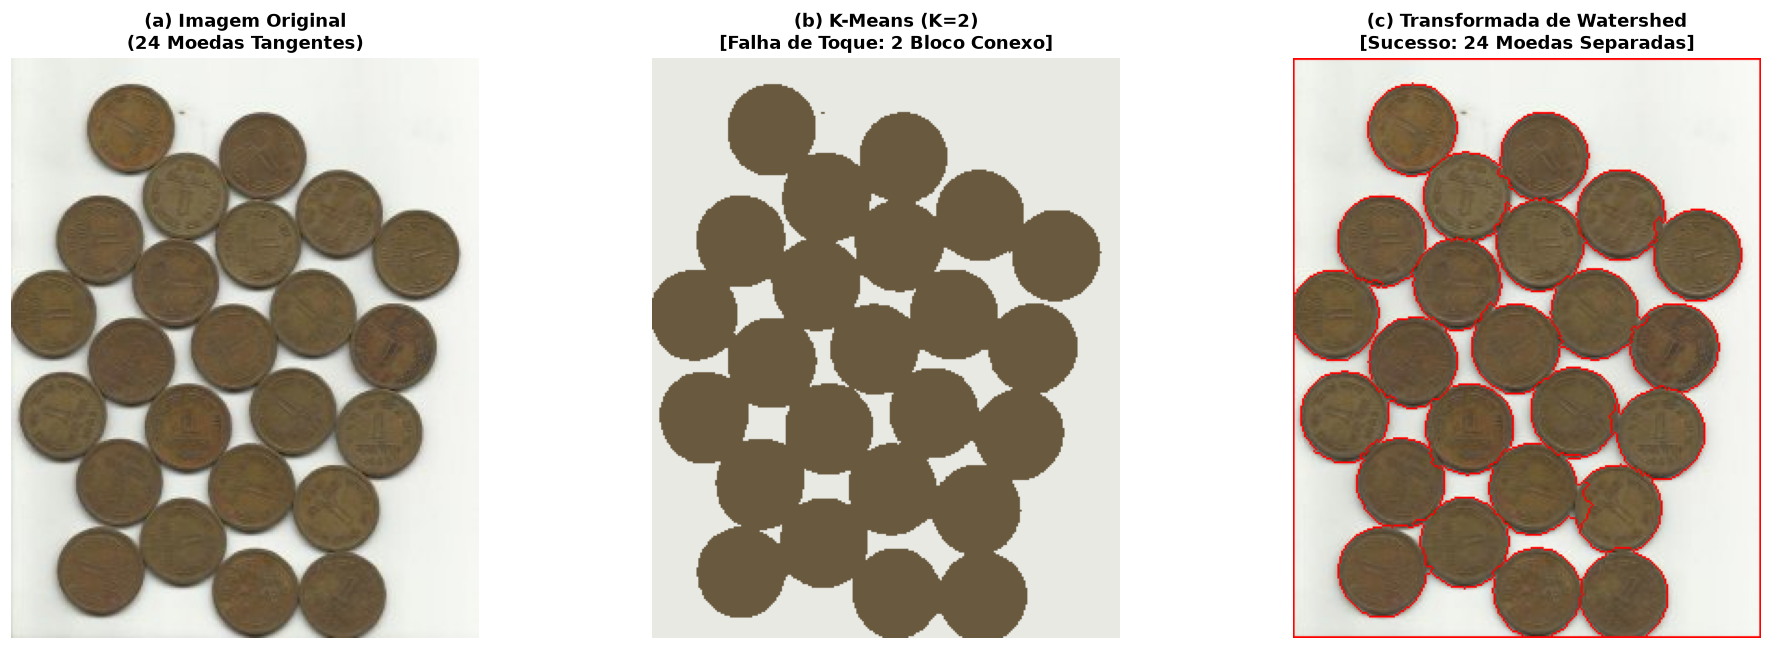

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(img_rgb)
axes[0].set_title("(a) Imagem Original\n(24 Moedas Tangentes)", fontsize=12, fontweight='bold')
axes[0].axis("off")

axes[1].imshow(seg_k2)
axes[1].set_title(f"(b) K-Means (K=2)\n[Falha de Toque: {qtd_kmeans} Bloco Conexo]", fontsize=12, fontweight='bold')
axes[1].axis("off")

axes[2].imshow(img_ws_result)
axes[2].set_title(f"(c) Transformada de Watershed\n[Sucesso: {moedas_ws} Moedas Separadas]", fontsize=12, fontweight='bold')
axes[2].axis("off")

plt.tight_layout()
out_duelo = os.path.join("resultados", "comparativo_toque_watershed_vs_kmeans.png")
plt.savefig(out_duelo, dpi=180, bbox_inches='tight')
print("Figura comparativa salva em:", out_duelo)
plt.show()


### 4. Sintese das Tres Dimensoes Comparativas (Slide 11)

| Dimensao Tecnica | Transformada de Watershed | Clustering K-Means |
| :--- | :--- | :--- |
| **Separacao de Toque** | Resolve com precisao. Usa o relevo da Transformada de Distancia para erguer barragens no estrangulamento. | Ineficaz. Objetos encostados da mesma cor tem a mesma assinatura espectral e fundem-se no mesmo cluster. |
| **Dependencia de Bordas** | Elevada. Depende de gradientes ou contornos geometricos definidos para calcular distancias. | Independente. Segmenta texturas e cores mesmo com bordas difusas ou inexistentes. |
| **Prontidao para Analise** | Imediata. Entrega regioes fechadas com rotulos individuais para contagem e metrologia. | Requer Pos-processamento. Entrega grupos dispersos sem garantia de contiguidade regional. |
